<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_8_PostProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 8 — Постобработка результатов

Дедупликация текста из OCR (fuzzy matching), склейка детекций YOLO по временным окнам, анализ LLM-описаний и финальный сводный отчёт.

In [1]:
!pip install rapidfuzz pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

RESULTS_DIR = '/content/drive/MyDrive/cv-frames/результаты'

print('файлы в результатах:')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {f}')


Mounted at /content/drive
файлы в результатах:
  busiest_frame.png
  llm_detections.json
  llm_summary.png
  ocr_results.csv
  resnet_classifications.csv
  resnet_summary.png
  whisper_transcript.csv
  yolo_detections.csv
  yolo_summary.png


## 1. Дедупликация текста (OCR)

In [3]:
import pandas as pd
from rapidfuzz import fuzz, process

df_ocr = pd.read_csv(f'{RESULTS_DIR}/ocr_results.csv')
print(f'строк до дедупликации: {len(df_ocr)}')

def deduplicate(texts, threshold=85):
    unique = []
    for t in texts:
        if not unique:
            unique.append(t)
            continue
        best = process.extractOne(t, unique, scorer=fuzz.ratio)
        if best is None or best[1] < threshold:
            unique.append(t)
    return unique

unique = deduplicate(df_ocr['text'].dropna().tolist())
print(f'строк после дедупликации: {len(unique)}')
print('уникальные тексты:')
for t in unique[:10]:
    print(f'  {t}')

pd.DataFrame({'text': unique}).to_csv(f'{RESULTS_DIR}/ocr_dedup.csv', index=False, encoding='utf-8-sig')
print('сохранено: ocr_dedup.csv')


строк до дедупликации: 761
строк после дедупликации: 47
уникальные тексты:
  We're no strangers to love
  Любовь нам не чужда
  You know the rules and so do |
  Ты знаешь ee правила; как и я
  Afull commitment's what Im thinking of
  настроен серьезно
  Afull commitment's what I'm
  thinking of
  You wouldn't get this from any other guy
  От других парней такого не дождешься
сохранено: ocr_dedup.csv


## 2. Склейка детекций YOLO

In [4]:
df_det = pd.read_csv(f'{RESULTS_DIR}/yolo_detections.csv')

WINDOW = 5  # допустимый разрыв между кадрами одного события

def merge_detections(group):
    group = group.sort_values('frame_num').reset_index(drop=True)
    events = []
    start = group.iloc[0]
    prev  = start['frame_num']
    for _, row in group.iloc[1:].iterrows():
        if row['frame_num'] - prev > WINDOW:
            events.append({
                'class':       start['class'],
                'start_frame': start['frame_num'],
                'end_frame':   prev,
                'avg_conf':    round(group['conf'].mean(), 3),
            })
            start = row
        prev = row['frame_num']
    events.append({
        'class':       start['class'],
        'start_frame': start['frame_num'],
        'end_frame':   prev,
        'avg_conf':    round(group['conf'].mean(), 3),
    })
    return pd.DataFrame(events)

df_merged = (df_det
    .groupby('class', group_keys=False)
    .apply(merge_detections)
    .sort_values('start_frame')
    .reset_index(drop=True))

df_merged.to_csv(f'{RESULTS_DIR}/yolo_merged.csv', index=False)
print(f'детекций: {len(df_det)} -> событий: {len(df_merged)}')
df_merged


детекций: 556 -> событий: 465


/tmp/ipykernel_11434/914815342.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(merge_detections)


,class,start_frame,end_frame,avg_conf
0,person,30,30,0.824
1,person,150,150,0.824
2,cell phone,150,150,0.649
3,tie,180,180,0.518
4,person,180,180,0.824
...,...,...,...,...
460,person,12540,12540,0.824
461,person,12570,12570,0.824
462,person,12600,12600,0.824
463,person,12630,12630,0.824


## 3. Анализ LLM-описаний (OpenRouter)

In [5]:
import json
from collections import Counter

with open(f'{RESULTS_DIR}/llm_detections.json', encoding='utf-8') as f:
    llm_data = json.load(f)

print(f'обработано кадров: {len(llm_data)}')
print()

# собираем все объекты из описаний
all_objects = []
for item in llm_data:
    objects = item.get('objects', '')
    if objects and objects != 'ошибка':
        for obj in objects.split(','):
            obj = obj.strip().lower()
            if obj:
                all_objects.append(obj)

counter = Counter(all_objects)
print('топ-15 объектов из LLM:')
for obj, cnt in counter.most_common(15):
    print(f'  {obj}: {cnt}')


обработано кадров: 20

топ-15 объектов из LLM:
  man: 5
  person: 4
  text: 4
  brick wall: 4
  sunglasses: 3
  white shirt: 3
  long blonde hair: 2
  headphones: 2
  face: 2
  hair: 2
  shirt: 2
  stage: 2
  three people: 2
  window frames: 2
  microphone: 2


## 4. Визуализация результатов

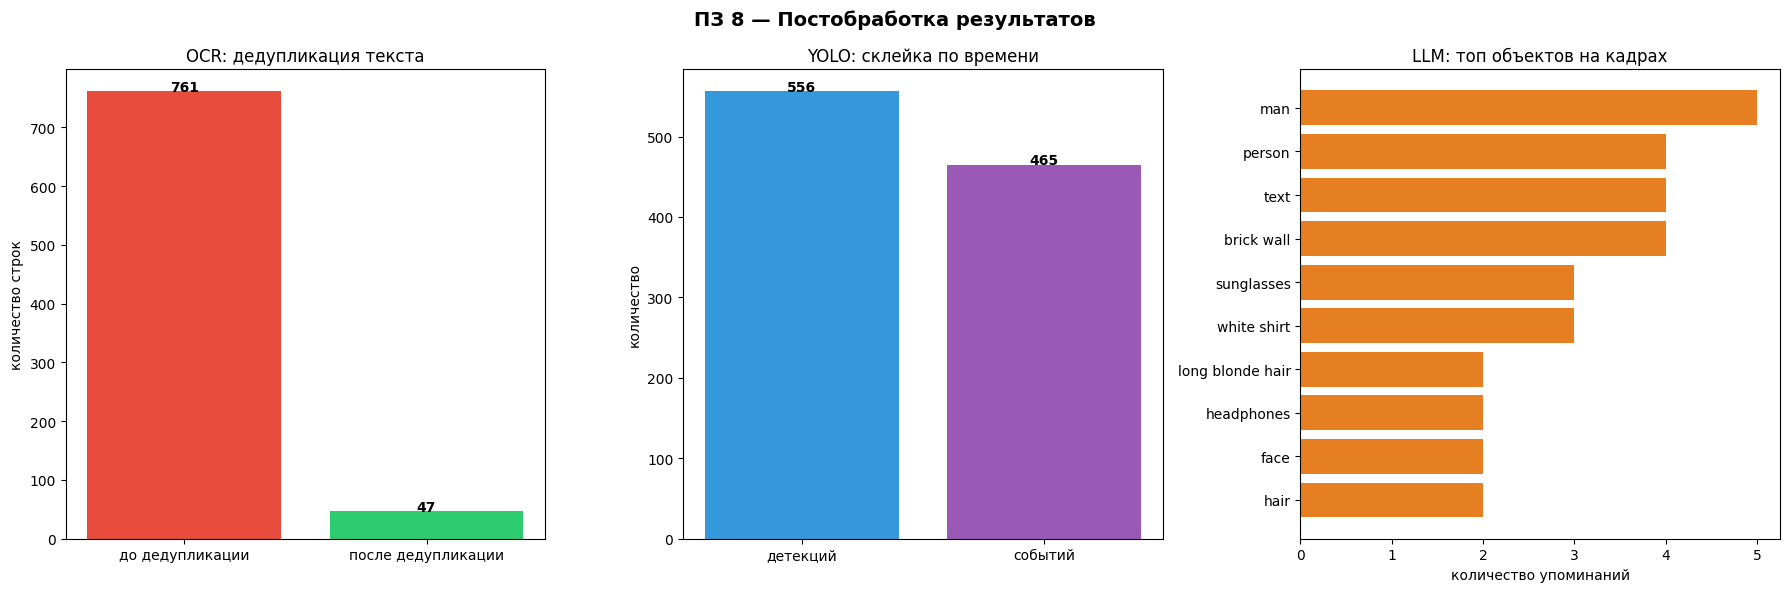

график сохранён: postprocessing_summary.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# OCR до/после
axes[0].bar(['до дедупликации', 'после дедупликации'],
            [len(df_ocr), len(unique)], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('OCR: дедупликация текста')
axes[0].set_ylabel('количество строк')
for i, v in enumerate([len(df_ocr), len(unique)]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# YOLO детекции vs события
axes[1].bar(['детекций', 'событий'],
            [len(df_det), len(df_merged)], color=['#3498db', '#9b59b6'])
axes[1].set_title('YOLO: склейка по времени')
axes[1].set_ylabel('количество')
for i, v in enumerate([len(df_det), len(df_merged)]):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Топ объектов LLM
top_obj = counter.most_common(10)
labels = [x[0][:20] for x in top_obj]
values = [x[1] for x in top_obj]
axes[2].barh(labels[::-1], values[::-1], color='#e67e22')
axes[2].set_title('LLM: топ объектов на кадрах')
axes[2].set_xlabel('количество упоминаний')

plt.suptitle('ПЗ 8 — Постобработка результатов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/postprocessing_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('график сохранён: postprocessing_summary.png')


## 5. Финальный отчёт

In [7]:
import json

report = {
    'ocr': {
        'total_texts': len(df_ocr),
        'unique_texts': len(unique),
        'dedup_ratio': round(len(unique) / max(len(df_ocr), 1), 3),
    },
    'yolo': {
        'total_detections': len(df_det),
        'merged_events': len(df_merged),
        'classes': df_merged['class'].unique().tolist(),
    },
    'llm': {
        'frames_processed': len(llm_data),
        'model': 'nvidia/nemotron-nano-12b-v2-vl:free (OpenRouter)',
        'top_objects': [obj for obj, _ in counter.most_common(10)],
    }
}

with open(f'{RESULTS_DIR}/final_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print('=== ФИНАЛЬНЫЙ ОТЧЁТ ===')
print(f"OCR: {report['ocr']['total_texts']} строк → {report['ocr']['unique_texts']} уникальных")
print(f"YOLO: {report['yolo']['total_detections']} детекций → {report['yolo']['merged_events']} событий")
print(f"LLM: {report['llm']['frames_processed']} кадров, модель: {report['llm']['model']}")
print(f"\nсохранено: final_report.json")


=== ФИНАЛЬНЫЙ ОТЧЁТ ===
OCR: 761 строк → 47 уникальных
YOLO: 556 детекций → 465 событий
LLM: 20 кадров, модель: nvidia/nemotron-nano-12b-v2-vl:free (OpenRouter)

сохранено: final_report.json
